# TP2 Run All - Ronda_11 Token Compression

One-click run for short, token-dense prompts. Prompts put the object identity first, remove weak wording, stay well below the 77-token CLIP limit, and use the Ronda 10 multi-seed validation runner.


## 1. Locate Project

In [1]:
from pathlib import Path
import os
import sys

START = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [START, *START.parents] if (p / "src" / "search_multiseed_validate.py").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing src/search_multiseed_validate.py")
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)


Project root: C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2
Python: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\.venv\Scripts\python.exe


## 2. Generate Ronda_11 Prompt Bank

In [2]:
import subprocess

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "src" / "gerar_ronda_11_token_compression.py"),
    "--output",
    str(PROJECT_ROOT / "prompts" / "refinement_ronda_11_token_compression.json"),
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)


Running: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\.venv\Scripts\python.exe C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\src\gerar_ronda_11_token_compression.py --output C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\prompts\refinement_ronda_11_token_compression.json


CompletedProcess(args=['c:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\.venv\\Scripts\\python.exe', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\src\\gerar_ronda_11_token_compression.py', '--output', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\prompts\\refinement_ronda_11_token_compression.json'], returncode=0)

## 3. Token Audit

In [3]:
import json
from pathlib import Path

prompt_path = PROJECT_ROOT / "prompts" / "refinement_ronda_11_token_compression.json"
data = json.loads(prompt_path.read_text(encoding="utf-8"))
try:
    from transformers import CLIPTokenizer
    tok = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14", local_files_only=True)
    counts = []
    for target, entries in data.items():
        vals = [len(tok(entry["prompt"], truncation=False, add_special_tokens=True)["input_ids"]) for entry in entries]
        counts.extend(vals)
        print(target, "max", max(vals), "avg", round(sum(vals) / len(vals), 1), "over77", sum(v > 77 for v in vals))
    print("total", len(counts), "max", max(counts), "over77", sum(v > 77 for v in counts))
except Exception as exc:
    print("Token audit skipped:", exc)
    print({target: len(entries) for target, entries in data.items()})


C:\Users\tugap\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1159_7.png max 24 avg 19.8 over77 0
9338.png max 27 avg 21.8 over77 0
total 540 max 27 over77 0


## 4. Multi-Seed Search

In [4]:
import subprocess

RUN_IDENTITY = "notebook_ronda_11_token_compression"
VALIDATION_TOP_N = 30
ENSEMBLE_PER_METRIC = 8
FINAL_TOP_K = 12
SEED_OFFSETS = ["1", "2", "3"]

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "src" / "search_multiseed_validate.py"),
    "--prompts", str(PROJECT_ROOT / "prompts" / "refinement_ronda_11_token_compression.json"),
    "--targets", str(PROJECT_ROOT / "TP2-students" / "students" / "tp2-chosen"),
    "--output-dir", str(PROJECT_ROOT / "TP2-students" / "students" / "outputs"),
    "--identity", RUN_IDENTITY,
    "--top-k", str(FINAL_TOP_K),
    "--stage1-save-k", "20",
    "--validation-top-n", str(VALIDATION_TOP_N),
    "--ensemble-per-metric", str(ENSEMBLE_PER_METRIC),
    "--seed-offsets", *SEED_OFFSETS,
    "--only", "1159_7.png", "9338.png",
    "--offline",
    "--disable-progress-bar",
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)


Running: c:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\.venv\Scripts\python.exe C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\src\search_multiseed_validate.py --prompts C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\prompts\refinement_ronda_11_token_compression.json --targets C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\tp2-chosen --output-dir C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs --identity notebook_ronda_11_token_compression --top-k 12 --stage1-save-k 20 --validation-top-n 30 --ensemble-per-metric 8 --seed-offsets 1 2 3 --only 1159_7.png 9338.png --offline --disable-progress-bar


CompletedProcess(args=['c:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\.venv\\Scripts\\python.exe', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\src\\search_multiseed_validate.py', '--prompts', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\prompts\\refinement_ronda_11_token_compression.json', '--targets', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\TP2-students\\students\\tp2-chosen', '--output-dir', 'C:\\Users\\tugap\\Desktop\\Universidade\\Masters2ºAno\\IAG\\Projeto 2\\TP2-students\\students\\outputs', '--identity', 'notebook_ronda_11_token_compression', '--top-k', '12', '--stage1-save-k', '20', '--validation-top-n', '30', '--ensemble-per-metric', '8', '--seed-offsets', '1', '2', '3', '--only', '1159_7.png', '9338.png', '--offline', '--disable-progress-bar'], returncode=0)

## 5. Show Latest Results

Latest Ronda_11 run: C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\20260519-192241_notebook_ronda_11_token_compression
Final ranking: C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\20260519-192241_notebook_ronda_11_token_compression\top12_robust_fixed_seed.csv
Contact sheet: C:\Users\tugap\Desktop\Universidade\Masters2ºAno\IAG\Projeto 2\TP2-students\students\outputs\20260519-192241_notebook_ronda_11_token_compression\contact_sheet_top12_robust.jpg


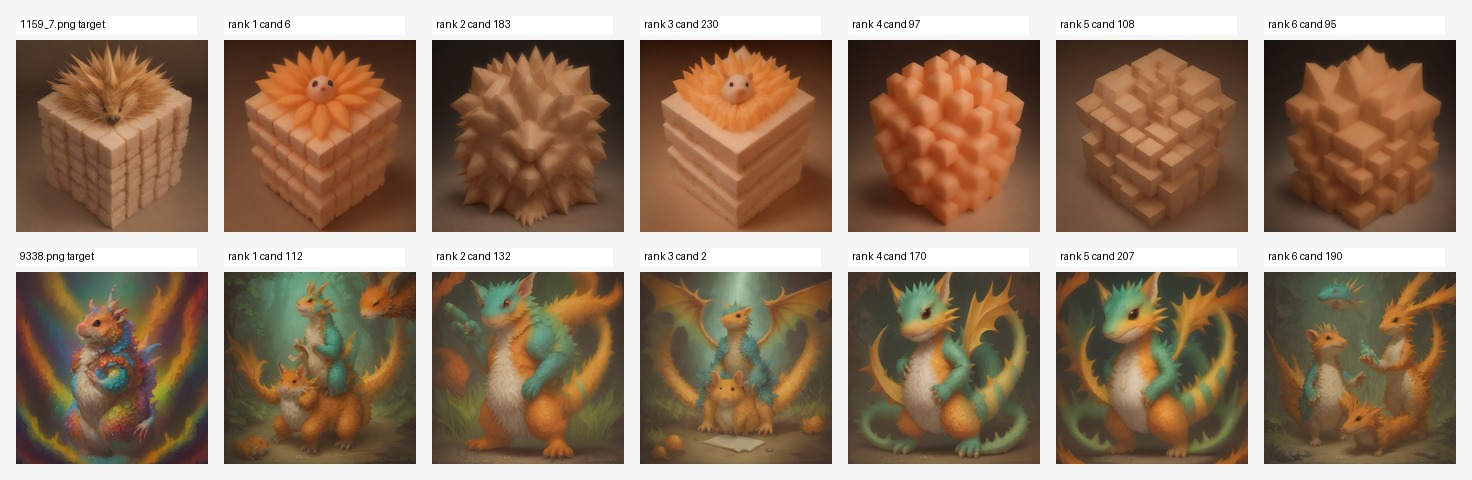

In [5]:
from IPython.display import display
from PIL import Image

outputs = PROJECT_ROOT / "TP2-students" / "students" / "outputs"
runs = sorted(outputs.glob("*notebook_ronda_11_token_compression"), key=lambda p: p.stat().st_mtime, reverse=True)
if not runs:
    raise FileNotFoundError("No Ronda_11 output folder found")
run_dir = runs[0]
print("Latest Ronda_11 run:", run_dir)
for path in sorted(run_dir.glob("top*_robust_fixed_seed.csv")):
    print("Final ranking:", path)
for path in sorted(run_dir.glob("contact_sheet_top*_robust.jpg")):
    print("Contact sheet:", path)
    display(Image.open(path))
